<a href="https://colab.research.google.com/github/shareotherban/CTC/blob/main/CTC_sc09_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
#uncomment if not working, and run the the cell
#!pip install colorama
from colorama import Fore, Style

print(Fore.BLUE+"Hello Speech to Text.."+Style.RESET_ALL)

Hello Speech to Text


In [52]:
# from google.colab import drive
# drive.mount('/content/drive')

In [53]:
#If u have DataSet files in your drive with this we can load them

# !rsync -ah --info=progress2 /content/drive/MyDrive/CTC/my_voice/ /content/my_voice

In [54]:
#If u don't have the DataSet
#This way is fast

from huggingface_hub import hf_hub_download
import zipfile
from pathlib import Path
import os

folder="/content/sc09"

if os.path.exists(folder):
  print("HuggingFace krandiash/sc09 Dataset is there.")
else:
  zip_path = hf_hub_download(
      repo_id="krandiash/sc09",
      filename="sc09.zip",
      repo_type="dataset",
  )

  extract_dir = Path("/content")

  with zipfile.ZipFile(zip_path, "r") as z:
      z.extractall(extract_dir)

  print("Extracted to:", extract_dir / "sc09")

In [ ]:
#convert all to same sample rate 16,000 Hz

import os

folder = "/content/CTC"

if os.path.exists(folder):
    print("Folder exists!")
else:
    print("Folder does not exist.")
    !git clone https://github.com/shareotherban/CTC.git
    !mv /content/CTC/resample_to_16k.sh /content/resample_to_16k.sh
    !unzip /content/CTC/my_voice-20260819T171106Z-1-001.zip -d /content/CTC/
    !mv /content/CTC/my_voice/ /content/
    !chmod +x resample_to_16k.sh
    !./resample_to_16k.sh
    !sudo rm -rf CTC

In [55]:
#check sample rate of audio if needed

from pathlib import Path
import torchaudio
from collections import Counter

audio_dir = Path("/content/my_voice/")

def sample_check():
  sample_rates = Counter()
  channels = Counter()

  for file in audio_dir.rglob("*.wav"):
      audio, sr = torchaudio.load(file)

      sample_rates[sr] += 1
      channels[audio.shape[0]] += 1

  print("Sample rates:")
  for sr, count in sample_rates.items():
      print(f"{sr} Hz: {count} files")

  print("\nChannels:")
  for ch, count in channels.items():
      name = "Mono" if ch == 1 else "Stereo" if ch == 2 else f"{ch} channels"
      print(f"{name}: {count} files")

sample_check()

Sample rates:
16000 Hz: 6 files

Channels:
Mono: 6 files


In [58]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [59]:
import os

data_dir = "sc09"
print(sorted(os.listdir(data_dir)))

['LICENSE', 'eight', 'five', 'four', 'nine', 'one', 'seven', 'six', 'testing_list.txt', 'three', 'two', 'validation_list.txt', 'zero']


In [60]:
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("Using device:", DEVICE)

# SAMPLE_RATE = 16000
# N_MELS      = 40
# WIN_MS      = 25
# HOP_MS      = 10
# BATCH_SIZE  = 1024
# NUM_EPOCHS  = 48
# LR          = 1e-2

# # Labels come from the folder names - change this list if classes change
# # LABEL_NAMES = ["zero", "one", "two", "three", "four",
# #                "five", "six", "seven", "eight", "nine"]

# LABEL_NAMES = ["zero", "one", "two", "three", "four",
#                "five", "six", "seven", "eight", "nine","cat"]

# word_to_idx = {w: i for i, w in enumerate(LABEL_NAMES)}

# NUM_LABELS  = len(LABEL_NAMES)
# BLANK       = NUM_LABELS        # CTC blank = one past the last real class
# NUM_CLASSES = NUM_LABELS + 1

# N_FFT      = int(WIN_MS / 1000 * SAMPLE_RATE)
# HOP_LENGTH = int(HOP_MS / 1000 * SAMPLE_RATE)

# # ---- Build official train/val/test splits from the list files ----
# def read_split_file(fname):
#     with open(os.path.join(data_dir, fname)) as f:
#         return set(line.strip() for line in f if line.strip())

# val_list  = read_split_file("validation_list.txt")
# test_list = read_split_file("testing_list.txt")

# train_files, val_files, test_files = [], [], []
# for word in LABEL_NAMES:
#     folder = os.path.join(data_dir, word)
#     for fname in sorted(os.listdir(folder)):
#         rel = f"{word}/{fname}"
#         if rel in test_list:
#             test_files.append(rel)
#         elif rel in val_list:
#             val_files.append(rel)
#         else:
#             train_files.append(rel)

# print(f"Classes: {LABEL_NAMES}")
# print(f"n_fft={N_FFT}, hop_length={HOP_LENGTH}, blank={BLANK}, num_classes={NUM_CLASSES}")
# print(f"train={len(train_files)}, val={len(val_files)}, test={len(test_files)}")



# # ---- Load my_voice custom data ----

# MY_VOICE_DIR = "my_voice"
# import random
# random.seed(42)

# my_voice_train, my_voice_val, my_voice_test = [], [], []
# if os.path.exists(MY_VOICE_DIR):
#     # Group files by label so each command is balanced across splits
#     label_to_files = {}
#     for fname in sorted(os.listdir(MY_VOICE_DIR)):
#         if not fname.endswith(".wav"):
#             continue
#         label_name = fname.split("_")[0]
#         if label_name not in word_to_idx:
#             continue          # skip unknown labels (e.g. cat, dog)
#         label_to_files.setdefault(label_name, []).append(fname)

#     for files in label_to_files.values():
#         random.shuffle(files)
#         n = len(files)
#         t_end = int(0.8 * n)
#         v_end = int(0.9 * n)
#         my_voice_train.extend(files[:t_end])
#         my_voice_val.extend(files[t_end:v_end])
#         my_voice_test.extend(files[v_end:])

# print(f"my_voice train={len(my_voice_train)}, val={len(my_voice_val)}, test={len(my_voice_test)}")



DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

SAMPLE_RATE = 16000
N_MELS      = 40
WIN_MS      = 25
HOP_MS      = 10
BATCH_SIZE  = 1024
NUM_EPOCHS  = 50
LR          = 0.002 #0.01–0.0001

LABEL_NAMES = ["zero", "one", "two", "three", "four",
               "five", "six", "seven", "eight", "nine","cat"]

word_to_idx = {w: i for i, w in enumerate(LABEL_NAMES)}

NUM_LABELS  = len(LABEL_NAMES)
BLANK       = NUM_LABELS
NUM_CLASSES = NUM_LABELS + 1

N_FFT      = int(WIN_MS / 1000 * SAMPLE_RATE)
HOP_LENGTH = int(HOP_MS / 1000 * SAMPLE_RATE)

#build train/val/test splits from SC09 list files
def read_split_file(fname):
    with open(os.path.join(data_dir, fname)) as f:
        return set(line.strip() for line in f if line.strip())

val_list  = read_split_file("validation_list.txt")
test_list = read_split_file("testing_list.txt")

train_files, val_files, test_files = [], [], []

# only scan folders that actually exist inside sc09/
sc09_labels = [w for w in LABEL_NAMES if os.path.isdir(os.path.join(data_dir, w))]

for word in sc09_labels:
    folder = os.path.join(data_dir, word)
    for fname in sorted(os.listdir(folder)):
        rel = f"{word}/{fname}"
        if rel in test_list:
            test_files.append(rel)
        elif rel in val_list:
            val_files.append(rel)
        else:
            train_files.append(rel)

print(f"Classes: {LABEL_NAMES}")
print(f"SC09 labels found: {sc09_labels}")
print(f"n_fft={N_FFT}, hop_length={HOP_LENGTH}, blank={BLANK}, num_classes={NUM_CLASSES}")
print(f"sc09 train={len(train_files)}, val={len(val_files)}, test={len(test_files)}")

#load DataSet from my_voice
MY_VOICE_DIR = "my_voice"
import random
random.seed(42)

my_voice_train, my_voice_val, my_voice_test = [], [], []
if os.path.exists(MY_VOICE_DIR):
    label_to_files = {}
    for fname in sorted(os.listdir(MY_VOICE_DIR)):
        if not fname.endswith(".wav"):
            continue
        label_name = fname.split("_")[0]
        if label_name not in word_to_idx:
            continue          # skip unknown labels
        label_to_files.setdefault(label_name, []).append(fname)

    for files in label_to_files.values():
        random.shuffle(files)
        n = len(files)
        t_end = int(0.8 * n)
        v_end = int(0.9 * n)
        my_voice_train.extend(files[:t_end])
        my_voice_val.extend(files[t_end:v_end])
        my_voice_test.extend(files[v_end:])

print(f"my_voice train={len(my_voice_train)}, val={len(my_voice_val)}, test={len(my_voice_test)}")





Using device: cuda
Classes: ['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'cat']
SC09 labels found: ['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine']
n_fft=400, hop_length=160, blank=11, num_classes=12
sc09 train=31158, val=3643, test=4107
my_voice train=3, val=0, test=3


In [61]:
import torch
import torchaudio

example_path = os.path.join(data_dir, train_files[0])
label = word_to_idx[train_files[0].split("/")[0]]

waveform, sample_rate = torchaudio.load(example_path)

print("File:", example_path)
print("Waveform tensor shape:", waveform.shape)
print("Sample rate:", sample_rate)
print("Min amplitude:", waveform.min().item())
print("Max amplitude:", waveform.max().item())
print(f"Duration: {waveform.shape[1] / sample_rate:.3f} seconds")
print("Label:", label, "->", LABEL_NAMES[label])

File: sc09/zero/004ae714_nohash_0.wav
Waveform tensor shape: torch.Size([1, 16000])
Sample rate: 16000
Min amplitude: -0.29180908203125
Max amplitude: 0.258880615234375
Duration: 1.000 seconds
Label: 0 -> zero


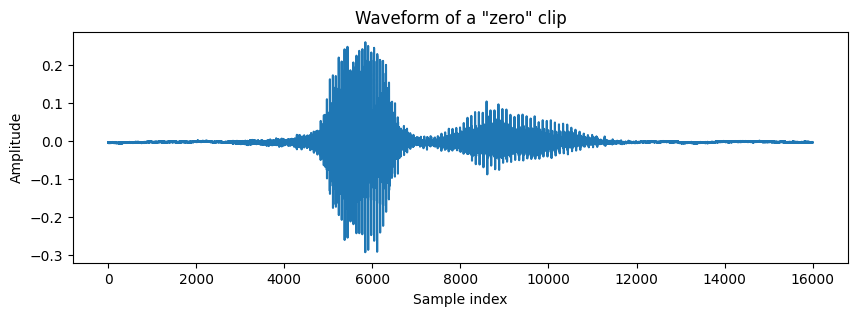

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))
plt.plot(waveform[0].numpy())
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.title(f'Waveform of a "{LABEL_NAMES[label]}" clip')
plt.show()

In [63]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=sample_rate,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS
)

mel_spec = mel_transform(waveform)
log_mel_spec = torch.log(mel_spec + 1e-9)

print("n_fft (samples per window):", N_FFT)
print("hop_length (samples between windows):", HOP_LENGTH)
print("Mel spectrogram shape:", mel_spec.shape)

n_fft (samples per window): 400
hop_length (samples between windows): 160
Mel spectrogram shape: torch.Size([1, 40, 101])


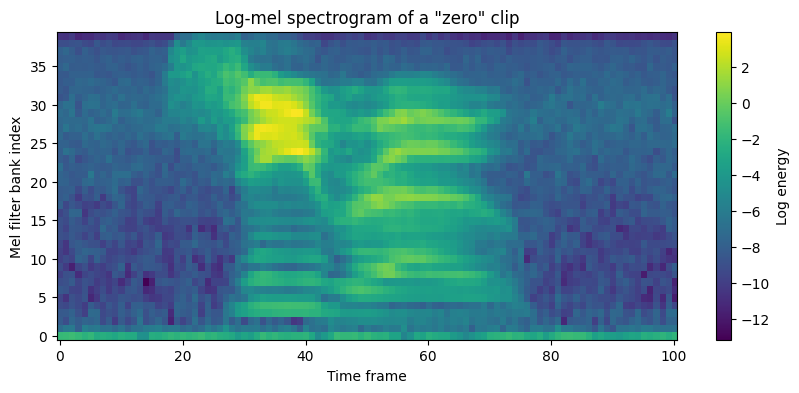

In [64]:
plt.figure(figsize=(10, 4))
plt.imshow(log_mel_spec[0].numpy(), origin="lower", aspect="auto", cmap="viridis")
plt.xlabel("Time frame")
plt.ylabel("Mel filter bank index")
plt.title(f'Log-mel spectrogram of a "{LABEL_NAMES[label]}" clip')
plt.colorbar(label="Log energy")
plt.show()

In [65]:
# from torch.utils.data import Dataset

# class SCDataset(Dataset):
#     def __init__(self, data_dir, file_list):
#         self.data_dir = data_dir
#         self.file_list = file_list
#         self.mel_transform = torchaudio.transforms.MelSpectrogram(
#             sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
#         )

#     def __len__(self):
#         return len(self.file_list)

#     def __getitem__(self, idx):
#         rel = self.file_list[idx]
#         waveform, sr = torchaudio.load(os.path.join(self.data_dir, rel))

#         if sr != SAMPLE_RATE:   # resample only if needed
#             waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)

#         label = word_to_idx[rel.split("/")[0]]
#         mel_spec = self.mel_transform(waveform)
#         log_mel_spec = torch.log(mel_spec + 1e-9)
#         return log_mel_spec.squeeze(0), label

from torch.utils.data import Dataset

class SCDataset(Dataset):
    def __init__(self, data_dir, file_list):
        self.data_dir = data_dir
        self.file_list = file_list
        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
        )

        # put in the cached
        self.data = []
        for rel in self.file_list:
            waveform, sr = torchaudio.load(os.path.join(self.data_dir, rel))
            if sr != SAMPLE_RATE:
                waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)


                #fix to fit multi folder
            #label = word_to_idx[rel.split("/")[0]]

            if "/" in rel:
                label_name = rel.split("/")[0]
            else:
                label_name = rel.split("_")[0]
            label = word_to_idx[label_name]

            mel_spec = self.mel_transform(waveform)
            log_mel_spec = torch.log(mel_spec + 1e-9)
            #normalization
            log_mel_spec = (log_mel_spec - log_mel_spec.mean()) / (log_mel_spec.std() + 1e-9)
            self.data.append((log_mel_spec.squeeze(0), label))

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        return self.data[idx]

In [66]:
dataset = SCDataset(data_dir, train_files)
spec, label = dataset[0]
print("Spectrogram shape:", spec.shape)
print("Label:", label, "->", LABEL_NAMES[label])

Spectrogram shape: torch.Size([40, 101])
Label: 0 -> zero


In [67]:
from torch.utils.data import DataLoader

try:
    loader = DataLoader(dataset, BATCH_SIZE)
    batch = next(iter(loader))
except RuntimeError as e:
    print("Error:", e)

Error: stack expects each tensor to be equal size, but got [40, 101] at entry 0 and [40, 79] at entry 1


In [68]:
def collate_fn(batch):
    specs, labels = zip(*batch)

    lengths = torch.tensor([s.shape[1] for s in specs])
    max_len = lengths.max().item()

    padded_specs = []
    for s in specs:
        pad_amount = max_len - s.shape[1]
        padded = torch.nn.functional.pad(s, (0, pad_amount))
        padded_specs.append(padded)

    #change to fit GPU
    specs_batch = torch.stack(padded_specs)
    labels_batch = torch.tensor(labels)
    specs_batch = specs_batch.to(DEVICE)
    labels_batch = labels_batch.to(DEVICE)
    lengths = lengths.to(DEVICE)

    return specs_batch, labels_batch, lengths

In [69]:
loader = DataLoader(dataset, BATCH_SIZE, collate_fn=collate_fn)
specs_batch, labels_batch, lengths = next(iter(loader))

print("Batch spectrogram shape:", specs_batch.shape)
print("Batch labels:", labels_batch)
print("Batch lengths:", lengths)

Batch spectrogram shape: torch.Size([1024, 40, 101])
Batch labels: tensor([0, 0, 0,  ..., 0, 0, 0], device='cuda:0')
Batch lengths: tensor([101,  79, 101,  ...,  30, 101, 101], device='cuda:0')


In [70]:
import torch.nn as nn

class CTCSpeechModel(nn.Module):
    def __init__(self, n_mels=N_MELS, hidden_size=128, num_classes=NUM_CLASSES):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=n_mels,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        rnn_out, _ = self.rnn(x)
        logits = self.classifier(rnn_out)
        return logits

In [71]:
#change to fit GPU
model = CTCSpeechModel().to(DEVICE)
logits = model(specs_batch.to(DEVICE))
print("Logits shape:", logits.shape)

Logits shape: torch.Size([1024, 101, 12])


In [72]:
criterion = nn.CTCLoss(blank=BLANK, zero_infinity=True)

log_probs = torch.nn.functional.log_softmax(logits, dim=2)
log_probs = log_probs.permute(1, 0, 2)

target_lengths = torch.ones(labels_batch.shape[0], dtype=torch.long)
targets = labels_batch

print("log_probs shape (T, batch, classes):", log_probs.shape)
print("lengths min/max:", lengths.min().item(), lengths.max().item())

#change to fit gpu
loss = criterion(log_probs, targets.to(DEVICE),
                 lengths.to(DEVICE), target_lengths.to(DEVICE))
print("Loss:", loss.item())

log_probs shape (T, batch, classes): torch.Size([101, 1024, 12])
lengths min/max: 30 101
Loss: 248.054931640625


In [73]:
# # sc09 ships with official train/validation/test splits - use them if present
# if {"train", "test"} <= set(ds.keys()):
#     train_split = ds["train"]
#     test_split = ds["test"]
#     print("Using the dataset's official train/test splits")
# else:
#     # fallback: 80/20 random split (reproducible)
#     import random
#     random.seed(42)
#     indices = list(range(len(ds["train"])))
#     random.shuffle(indices)
#     split_idx = int(0.8 * len(indices))
#     train_split = ds["train"].select(indices[:split_idx])
#     test_split = ds["train"].select(indices[split_idx:])
#     print("No official test split found - used an 80/20 random split")


#fix to handel multi file
# train_split, test_split = train_files, test_files
# print(f"Train examples: {len(train_split)}")
# print(f"Test examples: {len(test_split)}")


train_split, test_split = train_files, test_files
print(f"Train examples: {len(train_split)}")
print(f"Test examples: {len(test_split)}")
print(f"My voice train: {len(my_voice_train)}, test: {len(my_voice_test)}")

Train examples: 31158
Test examples: 4107
My voice train: 3, test: 3


In [74]:
# train_dataset = SCDataset(data_dir, train_files)
# test_dataset  = SCDataset(data_dir, test_files)

# train_loader = DataLoader(
#     train_dataset,
#     batch_size=BATCH_SIZE,
#     shuffle=True,       # reshuffle order every epoch during training
#     collate_fn=collate_fn
# )

# test_loader = DataLoader(
#     test_dataset,
#     batch_size=BATCH_SIZE,
#     shuffle=False,       # order doesn't matter for evaluation
#     collate_fn=collate_fn
# )

# print(f"Number of training batches: {len(train_loader)}")
# print(f"Number of test batches: {len(test_loader)}")

#fix for handel multi folder
from torch.utils.data import ConcatDataset

# SC09 datasets
sc09_train = SCDataset(data_dir, train_files)
sc09_test  = SCDataset(data_dir, test_files)

# my_voice datasets
my_voice_train_ds = SCDataset(MY_VOICE_DIR, my_voice_train)
my_voice_test_ds  = SCDataset(MY_VOICE_DIR, my_voice_test)

# combined datasets
train_dataset = ConcatDataset([sc09_train, my_voice_train_ds])
test_dataset  = ConcatDataset([sc09_test,  my_voice_test_ds])

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")


Number of training batches: 31
Number of test batches: 5


In [75]:
print("Classes:", LABEL_NAMES)
print("NUM_CLASSES:", NUM_CLASSES)

# check model work on my_voice sample
if my_voice_train:
    mv_ds = SCDataset(MY_VOICE_DIR, my_voice_train)
    spec, lbl = mv_ds[0]
    print("My voice sample label:", lbl, "->", LABEL_NAMES[lbl])
    print("Spectrogram shape:", spec.shape)

Classes: ['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'cat']
NUM_CLASSES: 12
My voice sample label: 7 -> seven
Spectrogram shape: torch.Size([40, 263])


In [76]:
# model = CTCSpeechModel().to(DEVICE)
# optimizer = torch.optim.Adam(model.parameters(), lr=LR)
# criterion = nn.CTCLoss(blank=BLANK, zero_infinity=True)

# num_epochs = NUM_EPOCHS

# for epoch in range(num_epochs):

#     model.train()
#     total_train_loss = 0.0

#     for specs_batch, labels_batch, lengths in train_loader:
#       #add to fit GPU
#         specs_batch = specs_batch.to(DEVICE)
#         labels_batch = labels_batch.to(DEVICE)
#         lengths = lengths.to(DEVICE)

#         optimizer.zero_grad()

#         logits = model(specs_batch)
#         log_probs = torch.nn.functional.log_softmax(logits, dim=2)
#         log_probs = log_probs.permute(1, 0, 2)

#         target_lengths = torch.ones(labels_batch.shape[0], dtype=torch.long, device=DEVICE)
#         loss = criterion(log_probs, labels_batch, lengths, target_lengths)

#         loss.backward()
#         optimizer.step()

#         total_train_loss += loss.item()

#     avg_train_loss = total_train_loss / len(train_loader)

#     model.eval()
#     total_test_loss = 0.0

#     with torch.no_grad():
#         for specs_batch, labels_batch, lengths in test_loader:
#             #add to fit GPU
#             specs_batch = specs_batch.to(DEVICE)
#             labels_batch = labels_batch.to(DEVICE)
#             lengths = lengths.to(DEVICE)


#             logits = model(specs_batch)
#             log_probs = torch.nn.functional.log_softmax(logits, dim=2)
#             log_probs = log_probs.permute(1, 0, 2)

#             #add to change GPU
#             target_lengths = torch.ones(labels_batch.shape[0], dtype=torch.long)
#             target_lengths = torch.ones(labels_batch.shape[0], dtype=torch.long, device=DEVICE)

#             loss = criterion(log_probs, labels_batch, lengths, target_lengths)

#             total_test_loss += loss.item()

#     avg_test_loss = total_test_loss / len(test_loader)

#     print(f"Epoch {epoch+1}/{num_epochs} | Train loss: {avg_train_loss:.4f} | Test loss: {avg_test_loss:.4f}")


model = CTCSpeechModel().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CTCLoss(blank=BLANK, zero_infinity=True)

#this will track and stop when overfitting
# minimize test loss
# if stuck cut cut LR half
# wait 3 epochs before cutting the LR

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

# stop if no improvement for 8 epochs
best_test_loss   = float('inf')
patience_counter = 0
max_patience     = 8
best_model_state = None

num_epochs = NUM_EPOCHS

for epoch in range(num_epochs):

  #train part
    model.train()
    total_train_loss = 0.0

    for specs_batch, labels_batch, lengths in train_loader:
        specs_batch = specs_batch.to(DEVICE)
        labels_batch = labels_batch.to(DEVICE)
        lengths = lengths.to(DEVICE)

        optimizer.zero_grad()

        logits = model(specs_batch)
        log_probs = torch.nn.functional.log_softmax(logits, dim=2)
        log_probs = log_probs.permute(1, 0, 2)

        target_lengths = torch.ones(labels_batch.shape[0], dtype=torch.long, device=DEVICE)
        loss = criterion(log_probs, labels_batch, lengths, target_lengths)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

#test part
    model.eval()
    total_test_loss = 0.0

    with torch.no_grad():
        for specs_batch, labels_batch, lengths in test_loader:
            specs_batch = specs_batch.to(DEVICE)
            labels_batch = labels_batch.to(DEVICE)
            lengths = lengths.to(DEVICE)

            logits = model(specs_batch)
            log_probs = torch.nn.functional.log_softmax(logits, dim=2)
            log_probs = log_probs.permute(1, 0, 2)

            target_lengths = torch.ones(labels_batch.shape[0], dtype=torch.long, device=DEVICE)
            loss = criterion(log_probs, labels_batch, lengths, target_lengths)

            total_test_loss += loss.item()

    avg_test_loss = total_test_loss / len(test_loader)

    scheduler.step(avg_test_loss)
    current_lr = optimizer.param_groups[0]['lr']

    improved = False
    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        best_model_state = model.state_dict()
        patience_counter = 0
        improved = True
    else:
        patience_counter += 1

    status = " <<< BEST" if improved else ""
    print(f"Epoch {epoch+1}/{num_epochs} | Train: {avg_train_loss:.4f} | Test: {avg_test_loss:.4f} | LR: {current_lr:.1e}{status}")

    if patience_counter >= max_patience:
        print(f"\nEarly stopping — no improvement for {max_patience} epochs.")
        break

#set the best fitting
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\nLoaded best model (test loss = {best_test_loss:.4f})")

Epoch 1/50 | Train: 30.4555 | Test: 3.9319 | LR: 2.0e-03 <<< BEST
Epoch 2/50 | Train: 3.4392 | Test: 3.3525 | LR: 2.0e-03 <<< BEST
Epoch 3/50 | Train: 3.3077 | Test: 3.3242 | LR: 2.0e-03 <<< BEST
Epoch 4/50 | Train: 3.2962 | Test: 3.3047 | LR: 2.0e-03 <<< BEST
Epoch 5/50 | Train: 3.2836 | Test: 3.2803 | LR: 2.0e-03 <<< BEST
Epoch 6/50 | Train: 3.2613 | Test: 3.2565 | LR: 2.0e-03 <<< BEST
Epoch 7/50 | Train: 3.2159 | Test: 3.1817 | LR: 2.0e-03 <<< BEST
Epoch 8/50 | Train: 3.1264 | Test: 3.0690 | LR: 2.0e-03 <<< BEST
Epoch 9/50 | Train: 2.9962 | Test: 2.9135 | LR: 2.0e-03 <<< BEST
Epoch 10/50 | Train: 2.8161 | Test: 2.7039 | LR: 2.0e-03 <<< BEST
Epoch 11/50 | Train: 2.5767 | Test: 2.4616 | LR: 2.0e-03 <<< BEST
Epoch 12/50 | Train: 2.3201 | Test: 2.2428 | LR: 2.0e-03 <<< BEST
Epoch 13/50 | Train: 2.0907 | Test: 1.9734 | LR: 2.0e-03 <<< BEST
Epoch 14/50 | Train: 1.8652 | Test: 1.7850 | LR: 2.0e-03 <<< BEST
Epoch 15/50 | Train: 1.6892 | Test: 1.6167 | LR: 2.0e-03 <<< BEST
Epoch 16/50 | Trai

In [77]:
# # #greedy_decode
# def greedy_decode(logits, lengths):
#     pred_indices = torch.argmax(logits, dim=2)

#     decoded_batch = []
#     for i, sequence in enumerate(pred_indices):
#         real_length = lengths[i].item()
#         sequence = sequence[:real_length].tolist()

#         collapsed = []
#         previous = None
#         for idx in sequence:
#             if idx != previous:
#                 collapsed.append(idx)
#             previous = idx
#         decoded = [c for c in collapsed if c != BLANK]
#         decoded_batch.append(decoded)

#     return decoded_batch

In [78]:
# model.eval()
# correct = 0
# total = 0

# with torch.no_grad():
#     for specs_batch, labels_batch, lengths in test_loader:
#         logits = model(specs_batch)
#         predictions = greedy_decode(logits, lengths)

#         for pred, true_label in zip(predictions, labels_batch.tolist()):
#             if pred == [true_label]:
#                 correct += 1
#             total += 1

# print(f"Test accuracy: {correct}/{total} = {correct/total:.2%}")

In [79]:
import math
from collections import defaultdict

NEG_INF = float("-inf")

def logaddexp(*args):
    m = max(args)
    if m == NEG_INF:
        return NEG_INF
    return m + math.log(sum(math.exp(a - m) for a in args))


def beam_search_single(log_probs, beam_width=10, blank=BLANK):
    lp = log_probs.tolist()
    beams = {(): (0.0, NEG_INF)}

    for t in range(len(lp)):
        new_beams = defaultdict(lambda: (NEG_INF, NEG_INF))
        for prefix, (p_b, p_nb) in beams.items():
            for c, p in enumerate(lp[t]):
                if c == blank:
                    o_b, o_nb = new_beams[prefix]
                    new_beams[prefix] = (logaddexp(o_b, p_b + p, p_nb + p), o_nb)
                else:
                    last = prefix[-1] if prefix else None
                    if c == last:
                        #("aa" -> "a")...
                        o_b, o_nb = new_beams[prefix]
                        new_beams[prefix] = (o_b, logaddexp(o_nb, p_nb + p))
                        # ("a_a" -> "aa")
                        ext = prefix + (c,)
                        n_b, n_nb = new_beams[ext]
                        new_beams[ext] = (n_b, logaddexp(n_nb, p_b + p))
                    else:
                        ext = prefix + (c,)
                        n_b, n_nb = new_beams[ext]
                        new_beams[ext] = (n_b, logaddexp(n_nb, p_b + p, p_nb + p))

        beams = dict(sorted(new_beams.items(),
                            key=lambda kv: logaddexp(*kv[1]),
                            reverse=True)[:beam_width])

    best_prefix, (p_b, p_nb) = max(beams.items(), key=lambda kv: logaddexp(*kv[1]))
    return list(best_prefix), logaddexp(p_b, p_nb)


def beam_search_decode(logits, lengths, beam_width=10, blank=BLANK):
    log_probs = torch.nn.functional.log_softmax(logits, dim=2)

    decoded_batch = []
    for i in range(log_probs.shape[0]):
        real_length = lengths[i].item()
        sequence, score = beam_search_single(
            log_probs[i, :real_length], beam_width=beam_width, blank=blank
        )
        decoded_batch.append(sequence)

    return decoded_batch

In [80]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for specs_batch, labels_batch, lengths in test_loader:
      #change to fit GPU
        specs_batch = specs_batch.to(DEVICE)
        logits = model(specs_batch)
        predictions = beam_search_decode(logits.cpu(), lengths, beam_width=10)

        for pred, true_label in zip(predictions, labels_batch.tolist()):
            if pred == [true_label]:
                correct += 1
            total += 1

print(f"Beam search test accuracy: {correct}/{total} = {correct/total:.2%}")

Beam search test accuracy: 3949/4110 = 96.08%


In [81]:
print(Fore.LIGHTGREEN_EX + "Train By My OWN DataSet/Voice..." + Style.RESET_ALL)
print(Fore.BLUE+ "Name Files Format: cat_0_audio.wav"+ Style.RESET_ALL)

Train By My OWN DataSet/Voice...
Name Files Format: cat_0_audio.wav


In [82]:
from google.colab import files
import torchaudio
import torch
import os
import shutil

MY_VOICE_DIR = "/content/my_voice"
os.makedirs(MY_VOICE_DIR, exist_ok=True)

In [83]:
def predict_wav(path, model, device=DEVICE, beam_width=10):
    model.eval()
    waveform, sr = torchaudio.load(path)
    # stereo -> mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != SAMPLE_RATE:
        waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)

    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    log_mel_spec = torch.log(mel_transform(waveform) + 1e-9)
    log_mel_spec = (log_mel_spec - log_mel_spec.mean()) / (log_mel_spec.std() + 1e-9)

    spec = log_mel_spec.squeeze(0).unsqueeze(0).to(device)
    length = torch.tensor([spec.shape[2]])

    with torch.no_grad():
        logits = model(spec)
        pred = beam_search_decode(logits.cpu(), length, beam_width=beam_width)[0]

    print("Predicted:", [LABEL_NAMES[i] for i in pred])
    return pred

In [84]:
def next_index_for_label(label, folder=MY_VOICE_DIR):
    existing = [f for f in os.listdir(folder) if f.startswith(f"{label}_") and f.endswith("_audio.wav")]
    used_indices = []
    for f in existing:
        try:
            idx = int(f[len(label)+1:-len("_audio.wav")])
            used_indices.append(idx)
        except ValueError:
            continue
    return max(used_indices, default=-1) + 1

In [85]:
def label_and_save(path, model, device=DEVICE, beam_width=10):
    """Predicts a wav, it will ask to confirm if it is right, then saves it into my_voice/ as label_index_audio.wav"""
    pred = predict_wav(path, model, device=device, beam_width=beam_width)
    predicted_label = LABEL_NAMES[pred[0]] if len(pred) > 0 else "unknown"

    answer = input(f"Is '{predicted_label}' correct? (y/n): ").strip().lower()
    if answer == "y":
        final_label = predicted_label
    else:
        final_label = input("What is the correct word? ").strip().lower()

    idx = next_index_for_label(final_label)
    new_filename = f"{final_label}_{idx}_audio.wav"
    new_path = os.path.join(MY_VOICE_DIR, new_filename)

    shutil.copy(path, new_path)
    print(f"Saved as: {new_path}")
    return new_path

In [86]:
uploaded = files.upload()


for uploaded_filename in uploaded.keys():
    uploaded_path = "/content/" + uploaded_filename
    print("\nUploaded:", uploaded_path)
    label_and_save(uploaded_path, model)

Saving NA_0_audio.wav to NA_0_audio.wav
Saving 3_0_audio.wav to 3_0_audio.wav
Saving 2_1_audio.wav to 2_1_audio.wav
Saving 2_0_audio.wav to 2_0_audio.wav
Saving 1_3_audio.wav to 1_3_audio.wav
Saving 1_1_audio.wav to 1_1_audio.wav
Saving 1_0_audio.wav to 1_0_audio.wav

Uploaded: /content/NA_0_audio.wav
Predicted: ['seven']
Is 'seven' correct? (y/n): n
What is the correct word? NA
Saved as: /content/my_voice/na_0_audio.wav

Uploaded: /content/3_0_audio.wav
Predicted: ['three']
Is 'three' correct? (y/n): y
Saved as: /content/my_voice/three_0_audio.wav

Uploaded: /content/2_1_audio.wav
Predicted: ['two']
Is 'two' correct? (y/n): y
Saved as: /content/my_voice/two_0_audio.wav

Uploaded: /content/2_0_audio.wav
Predicted: ['two']
Is 'two' correct? (y/n): y
Saved as: /content/my_voice/two_1_audio.wav

Uploaded: /content/1_3_audio.wav
Predicted: ['one']
Is 'one' correct? (y/n): y
Saved as: /content/my_voice/one_1_audio.wav

Uploaded: /content/1_1_audio.wav
Predicted: ['five']
Is 'five' correct? 

In [87]:
#only if need to upload the data set to google drive
#rsync -avh --info=progress2 my_voice /content/drive/MyDrive/CTC
#rsync -avh --info=progress2 sc09 /content/drive/MyDrive/CTC